In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.stats import spearmanr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.svm import LinearSVR
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed
import time as tm
import pickle

mne.set_log_level('WARNING')
%matplotlib inline

print(f'MNE version: {mne.__version__}')

MNE version: 1.12.1


In [3]:
# ruta raiz donde estan las carpetas de cada sujeto
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

# sujetos disponibles
subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [4]:
# creamos listas vacías donde iremos guardando los datos de cada sujeto
all_main_epochs  = []
all_main_rawdata = []
subjs_ok         = []

for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    file_main = os.path.join(subj_path, 'main_epo.fif')

    # comprobamos que existe el archivo
    if not os.path.exists(file_main):
        print(f'  {subject_id}: falta main_epo.fif, se omite')
        continue

    try:
        main = mne.read_epochs(file_main, preload=True, verbose=False)

        all_main_epochs.append(main)
        all_main_rawdata.append({
            'epoch_dat': main.get_data(),  # array (n_trials × 32 × 2876)
            'metadata':  main.metadata     # tabla con deci, confi, rDV, nrep...
        })

        subjs_ok.append(subject_id)
        print(f'  {subject_id} cargado — shape: {main.get_data().shape}')

    except Exception as e:
        print(f'  {subject_id}: error al cargar → {e}')

nSubj  = len(subjs_ok)
time   = all_main_epochs[0].times  # vector de timepoints (2876,)
n_time = len(time)
print(f'\nTotal sujetos cargados: {nSubj}')
print(f'Timepoints: {n_time}  |  Ventana: {time[0]:.2f}s → {time[-1]:.2f}s')

  s01 cargado — shape: (250, 32, 2876)
  s02 cargado — shape: (261, 32, 2876)
  s03 cargado — shape: (256, 32, 2876)
  s04 cargado — shape: (236, 32, 2876)
  s05 cargado — shape: (243, 32, 2876)
  s06: falta main_epo.fif, se omite
  s07 cargado — shape: (249, 32, 2876)
  s08 cargado — shape: (247, 32, 2876)
  s09 cargado — shape: (193, 32, 2876)
  s0x: falta main_epo.fif, se omite
  s10 cargado — shape: (250, 32, 2876)
  s11 cargado — shape: (251, 32, 2876)
  s12 cargado — shape: (252, 32, 2876)
  s13 cargado — shape: (253, 32, 2876)
  s14 cargado — shape: (261, 32, 2876)
  s15 cargado — shape: (257, 32, 2876)
  s16 cargado — shape: (238, 32, 2876)
  s17 cargado — shape: (260, 32, 2876)
  s18 cargado — shape: (239, 32, 2876)
  s19 cargado — shape: (259, 32, 2876)
  s20 cargado — shape: (248, 32, 2876)
  s21 cargado — shape: (257, 32, 2876)
  s22 cargado — shape: (264, 32, 2876)
  s23 cargado — shape: (255, 32, 2876)
  s24 cargado — shape: (232, 32, 2876)
  s25 cargado — shape: (264, 32

In [ ]:
# definimos las funciones auxiliares que usaran los clasificadores y regresores

# AngularRegression 
# clasificador adaptado a orientaciones circulares — igual que en la notebook anterior
# convierte el angulo en cos(2θ) y sin(2θ) para manejar la simetria de los gratings (0° = 180°)
class AngularRegression(BaseEstimator, RegressorMixin):
    def __init__(self, clf=None):
        self.clf = clf if clf is not None else LinearSVR()

    def fit(self, X, y):
        self.clf_cos = clone(self.clf)
        self.clf_sin = clone(self.clf)
        self.clf_cos.fit(X, np.cos(2 * y))
        self.clf_sin.fit(X, np.sin(2 * y))
        return self

    def predict(self, X):
        cos_pred = self.clf_cos.predict(X)
        sin_pred = self.clf_sin.predict(X)
        return np.arctan2(sin_pred, cos_pred) / 2

#  scorer_angle 
# mide que tan bien predijo el clasificador la orientacion
# usa la correlacion circular — resultado entre 0 (azar) y 1 (perfecto)
def scorer_angle(y_true, y_pred):
    error = 2 * y_true - 2 * y_pred
    return np.mean(np.cos(error))

#  create_folds 
# crea 5 folds estratificados: cada fold tiene trials de todas las clases
# random_state=42 para que la division sea siempre la misma (reproducibilidad)
def create_folds(y_binned, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

#  decode_timepoint_deci 
# funcion que procesa un solo timepoint para decodificar la decision (deci)
# usa LDA como clasificador — se ejecutara en paralelo sobre todos los timepoints
def decode_timepoint_deci(it, Y, labels, folds):
    Ytime  = Y[:, :, it] # actividad de todos los trials en ese instante exacto
    scaler = StandardScaler().fit(Ytime) # estandariza los datos (media 0, desviacion estandar 1)
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(labels), np.nan)
    clf    = LinearDiscriminantAnalysis()
    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        clf.fit(Ytime[train_ix], labels[train_ix]) # entrena con los trials de entrenamiento
        preds[test_ix] = clf.predict(Ytime[test_ix]) # predice los trials de test
    return preds

#  decode_timepoint_spearman 
# funcion que procesa un solo timepoint para decodificar confi o rDV
# usa correlacion de Spearman entre la actividad del EEG y la variable continua
# primero reduce los 32 canales a 1 dimension usando la norma L2 (magnitud del vector)
def decode_timepoint_spearman(it, Y, y_continuous):
    Ytime  = Y[:, :, it] # actividad de todos los trials en ese instante exacto
    scaler = StandardScaler().fit(Ytime) # estandariza los datos
    Ytime  = scaler.transform(Ytime)
    # reducimos los 32 canales a 1 dimension usando la norma L2
    # es decir, calculamos la magnitud del vector de actividad para cada trial
    eeg_magnitude = np.linalg.norm(Ytime, axis=1)  # (n_trials,)
    # calculamos la correlacion de Spearman entre la magnitud del EEG y la variable continua
    rho, _ = spearmanr(eeg_magnitude, y_continuous)
    return rho


## FASE 1 --> cross validation de 5 folds (80% train, 20% test) dentro de main_epo 

Variable a predecir: deci (0=diagonal, 1=cardinal) 

Clasificador: LDA



subj s01 (1/26)
  deci decodificado  → 0.1 min transcurridos

subj s02 (2/26)
  deci decodificado  → 0.2 min transcurridos

subj s03 (3/26)
  deci decodificado  → 0.3 min transcurridos

subj s04 (4/26)
  deci decodificado  → 0.4 min transcurridos

subj s05 (5/26)
  deci decodificado  → 0.4 min transcurridos

subj s07 (6/26)
  deci decodificado  → 0.5 min transcurridos

subj s08 (7/26)
  deci decodificado  → 0.6 min transcurridos

subj s09 (8/26)
  deci decodificado  → 0.7 min transcurridos

subj s10 (9/26)
  deci decodificado  → 0.7 min transcurridos

subj s11 (10/26)
  deci decodificado  → 0.8 min transcurridos

subj s12 (11/26)
  deci decodificado  → 0.9 min transcurridos

subj s13 (12/26)
  deci decodificado  → 1.0 min transcurridos

subj s14 (13/26)
  deci decodificado  → 1.0 min transcurridos

subj s15 (14/26)
  deci decodificado  → 1.1 min transcurridos

subj s16 (15/26)
  deci decodificado  → 1.2 min transcurridos

subj s17 (16/26)
  deci decodificado  → 1.3 min transcurridos



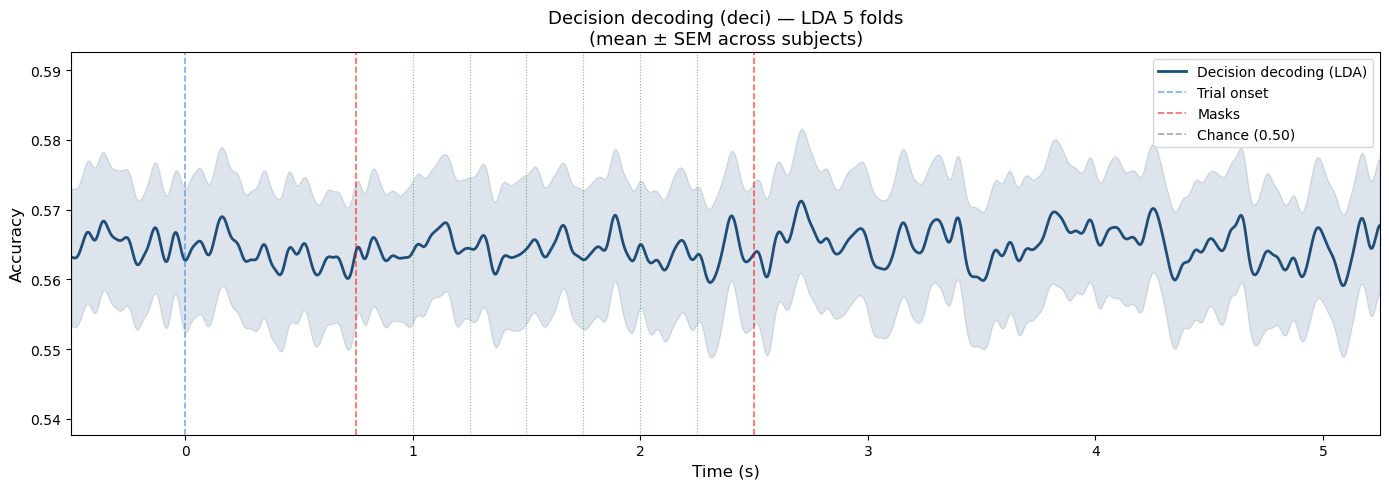

In [ ]:
# DECODING DE LA DECISION (deci) — LDA con 5 folds 
# queremos saber en que momento del trial el cerebro ya "sabe" que decision va a tomar
# deci es binaria: 0 = diagonal, 1 = cardinal
# usamos LDA como clasificador con 5 folds estratificados
# la metrica es accuracy (azar = 0.5 con 2 clases)

n_folds = 5

# array donde guardamos los resultados de accuracy (n_sujetos × n_timepoints)
scorer_deci = np.zeros((nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat'] # array (n_trials × 32 × 2876)
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    # labels: decision binaria (0 = diagonal, 1 = cardinal)
    labels = np.array(metadata['deci'], dtype=int)

    # creamos los 5 folds estratificados por la decision
    folds = create_folds(labels, n_folds)

    # procesamos todos los timepoints en paralelo usando todos los nucleos del Mac
    results_par = Parallel(n_jobs=-1)(
        delayed(decode_timepoint_deci)(it, Y, labels, folds)
        for it in range(n_time)
    )

    # convertimos la lista de arrays en una matriz (n_trials × n_time)
    preds_all = np.column_stack(results_par)

    # calculamos la accuracy para cada timepoint
    # accuracy = proporcion de trials donde el clasificador predijo la decision correcta
    for it in range(n_time):
        valid = ~np.isnan(preds_all[:, it])
        scorer_deci[isubj, it] = np.mean(
            preds_all[valid, it] == labels[valid].astype(float)
        )

    elapsed = (tm.time() - t_start) / 60
    print(f'  deci decodificado  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de deci completado — shape: {scorer_deci.shape}')

# guardamos resultados
results_deci = {
    'scorer_deci': scorer_deci,
    'time':        time,
    'subjs_ok':    subjs_ok,
}

save_path_deci = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_deci.pkl'
with open(save_path_deci, 'wb') as f:
    pickle.dump(results_deci, f)

print(f'resultados guardados en: {save_path_deci}')

# plot 
sigma = 10
scorer_deci_smooth = gaussian_filter1d(scorer_deci, sigma=sigma, axis=1)
scorer_mean = np.mean(scorer_deci_smooth, axis=0)
scorer_sem  = np.std(scorer_deci_smooth, axis=0) / np.sqrt(nSubj)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, scorer_mean, color='#1f4e79', lw=2, label='Decision decoding (LDA)')
ax.fill_between(time, scorer_mean - scorer_sem, scorer_mean + scorer_sem,
                color='#1f4e79', alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='Chance (0.50)')


y_min = scorer_mean.min() - scorer_sem.max() - 0.01
y_max = scorer_mean.max() + scorer_sem.max() + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])


ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding (deci) — LDA 5 folds\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

decoding de deci por nrep completado


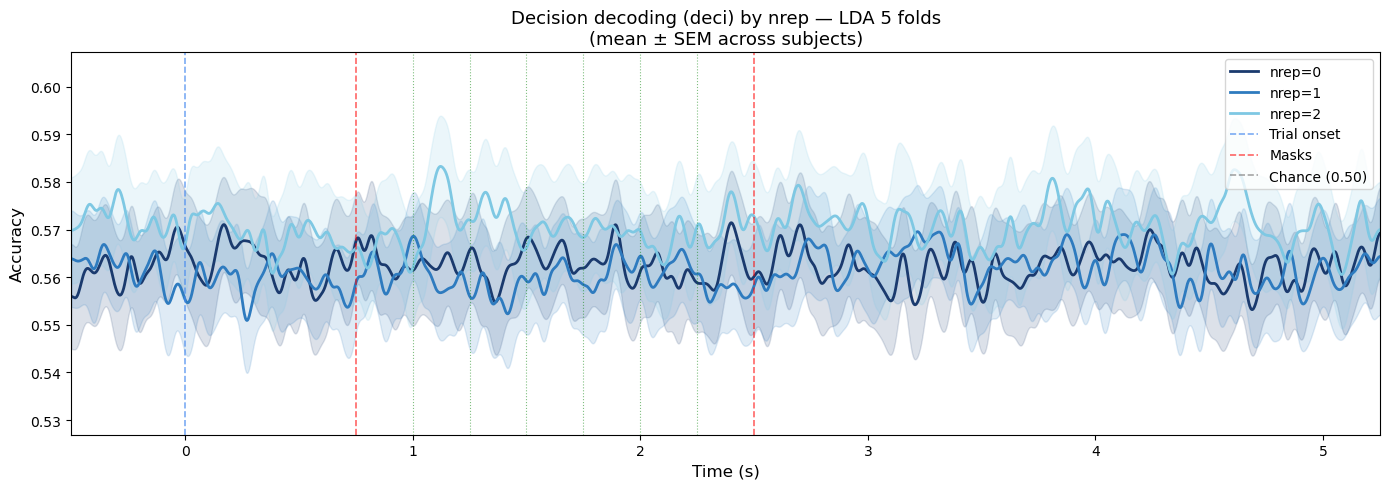

In [ ]:
# DECODING DE LA DECISION (deci) POR NREP
# reutilizamos las predicciones ya calculadas en la celda anterior
# filtramos los trials por nrep y calculamos la accuracy para cada nrep por separado
# si el sesgo de confirmacion aumenta con las repeticiones, esperamos ver
# que la accuracy sube con nrep — especialmente antes de que se presenten los estimulos

nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

# array donde guardamos los resultados por nrep (n_nreps × n_sujetos × n_timepoints)
scorer_deci_nrep = np.zeros((len(nreps), nSubj, n_time))

for isubj in range(nSubj):
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    # cargamos las predicciones ya calculadas para este sujeto
    preds = np.column_stack([
        decode_timepoint_deci(it,
                              all_main_rawdata[isubj]['epoch_dat'],
                              labels,
                              create_folds(labels, n_folds))
        for it in range(n_time)
    ])

    for i_nrep, nrep in enumerate(nreps):
        # indices de los trials con este nrep
        idx_nrep   = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) == 0:
            continue
        labels_nrep = labels[idx_nrep]
        preds_nrep  = preds[idx_nrep]

        # calculamos la accuracy para cada timepoint solo con los trials de este nrep
        for it in range(n_time):
            valid = ~np.isnan(preds_nrep[:, it])
            scorer_deci_nrep[i_nrep, isubj, it] = np.mean(
                preds_nrep[valid, it] == labels_nrep[valid].astype(float)
            )

print('decoding de deci por nrep completado')

# plot por nrep con escala adaptada
sigma = 10
scorer_deci_nrep_smooth = gaussian_filter1d(scorer_deci_nrep, sigma=sigma, axis=2)

fig, ax = plt.subplots(figsize=(14, 5))

for i_nrep, nrep in enumerate(nreps):
    mean = np.mean(scorer_deci_nrep_smooth[i_nrep], axis=0)
    sem  = np.std(scorer_deci_nrep_smooth[i_nrep], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=colors_nrep[i_nrep], lw=2, label=f'nrep={nrep}')
    ax.fill_between(time, mean - sem, mean + sem,
                    color=colors_nrep[i_nrep], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='Chance (0.50)')


all_means = np.array([
    np.mean(scorer_deci_nrep_smooth[i], axis=0) for i in range(len(nreps))
])
all_sems = np.array([
    np.std(scorer_deci_nrep_smooth[i], axis=0) / np.sqrt(nSubj) for i in range(len(nreps))
])

y_min = all_means.min() - all_sems.max() - 0.01
y_max = all_means.max() + all_sems.max() + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding (deci) by nrep — LDA 5 folds\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

Ventana de interes: 1.0s → 2.5s (751 timepoints)
Accuracy global: 0.5643 ± 0.0098
Nivel de azar:   0.5000
Mejora sobre el azar: 6.43%

Accuracy global por nrep:
  nrep=0: 0.5626 ± 0.0101  (mejora sobre azar: 6.26%)
  nrep=1: 0.5596 ± 0.0096  (mejora sobre azar: 5.96%)
  nrep=2: 0.5709 ± 0.0106  (mejora sobre azar: 7.09%)


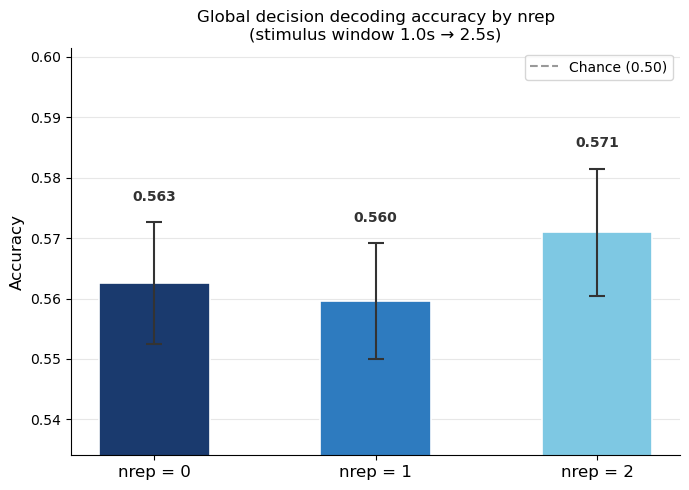

In [ ]:
# ACCURACY GLOBAL POR TRIAL
# en vez de ver la accuracy timepoint a timepoint, calculamos una sola metrica global
# usamos la ventana de presentacion de estimulos (1.0s a 2.5s) donde hay mas informacion
# esto nos da una respuesta directa a la pregunta: puede el EEG predecir la decision?

t_start_window = 1.0   # inicio de la ventana de interes (primer estimulo)
t_end_window   = 2.5   # fin de la ventana de interes (segunda mascara)

# indices de los timepoints dentro de esa ventana
idx_window = np.where((time >= t_start_window) & (time <= t_end_window))[0]

# accuracy global = media del score en esa ventana, promediada entre estimulos y sujetos
accuracy_global      = np.mean(scorer_deci[:, idx_window])
accuracy_global_sem  = np.std(np.mean(scorer_deci[:, idx_window], axis=1)) / np.sqrt(nSubj)
chance_level         = 0.5

print(f'Ventana de interes: {t_start_window}s → {t_end_window}s ({len(idx_window)} timepoints)')
print(f'Accuracy global: {accuracy_global:.4f} ± {accuracy_global_sem:.4f}')
print(f'Nivel de azar:   {chance_level:.4f}')
print(f'Mejora sobre el azar: {(accuracy_global - chance_level)*100:.2f}%')

# accuracy global por nrep
print(f'\nAccuracy global por nrep:')
for i_nrep, nrep in enumerate(nreps):
    acc_nrep = np.mean(scorer_deci_nrep[i_nrep, :, idx_window])
    sem_nrep = np.std(np.mean(scorer_deci_nrep[i_nrep, :, :][:, idx_window], axis=1)) / np.sqrt(nSubj)
    print(f'  nrep={nrep}: {acc_nrep:.4f} ± {sem_nrep:.4f}  '
          f'(mejora sobre azar: {(acc_nrep - chance_level)*100:.2f}%)')

# plot 
fig, ax = plt.subplots(figsize=(7, 5))

accs = [np.mean(scorer_deci_nrep[i, :, idx_window]) for i in range(len(nreps))]
sems = [np.std(np.mean(scorer_deci_nrep[i, :, :][:, idx_window], axis=1)) / np.sqrt(nSubj)
        for i in range(len(nreps))]

bars = ax.bar(nreps, accs, color=colors_nrep, width=0.5,
              edgecolor='white', linewidth=1.2, zorder=2)
ax.errorbar(nreps, accs, yerr=sems, fmt='none',
            color='#333333', capsize=6, capthick=1.5, lw=1.5, zorder=3)

# linea de azar
ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8, label='Chance (0.50)', zorder=1)

# etiquetas de accuracy encima de cada barra
for i, (acc, sem) in enumerate(zip(accs, sems)):
    ax.text(i, acc + sem + 0.003, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# adaptamos el eje Y
y_min = min(accs) - max(sems) - 0.015
y_max = max(accs) + max(sems) + 0.02
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])

ax.set_xticks(nreps)
ax.set_xticklabels([f'nrep = {n}' for n in nreps], fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Global decision decoding accuracy by nrep\n'
             '(stimulus window 1.0s → 2.5s)', fontsize=12)
ax.legend(fontsize=10)

# fondo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()

Grupos de canales:
  Frontal: 11 canales → ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz', 'FC1', 'FC2', 'FC5', 'FC6']
  Central: 7 canales → ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
  Occipital: 8 canales → ['O1', 'Oz', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz']
  All channels: 32 canales → ['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'LM', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'RM', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'Eye', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'Fz']

subj s01 (1/26)
  Frontal ✓  Central ✓  Occipital ✓  All channels ✓  → 0.5 min transcurridos

subj s02 (2/26)
  Frontal ✓  Central ✓  Occipital ✓  All channels ✓  → 1.0 min transcurridos

subj s03 (3/26)
  Frontal ✓  Central ✓  Occipital ✓  All channels ✓  → 1.3 min transcurridos

subj s04 (4/26)
  Frontal ✓  Central ✓  Occipital ✓  All channels ✓  → 1.5 min transcurridos

subj s05 (5/26)
  Frontal ✓  Central ✓  Occipital ✓  All channels ✓  → 1.6 min transcurridos

subj s07 (6/26)
  Frontal ✓  Centra

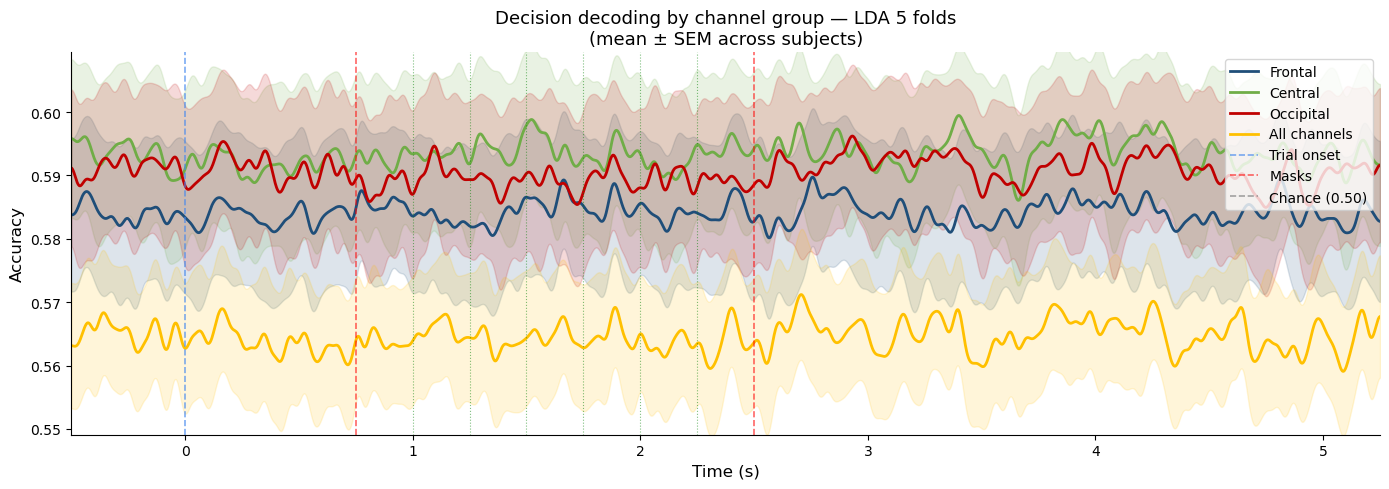

In [24]:
# TECNICA 2 — SELECCION DE CANALES FRONTALES Y CENTRALES 
# en vez de usar los 32 canales, usamos solo los canales frontales y centrales
# que son los mas relacionados con la toma de decisiones
# comparamos 3 grupos de canales: frontales, occipitales y todos
# esperamos que los frontales den mejor accuracy que los occipitales para la decision

# nombres de todos los canales en el orden en que estan en los datos
all_ch_names = all_main_epochs[0].ch_names

# definimos los grupos de canales
ch_groups = {
    'Frontal'     : ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz',
                     'FC1', 'FC2', 'FC5', 'FC6'],
    'Central'     : ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6'],
    'Occipital'   : ['O1', 'Oz', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz'],
    'All channels': all_ch_names
}

# convertimos los nombres de canales en indices para indexar el array de datos
ch_indices = {
    group: [all_ch_names.index(ch) for ch in chs if ch in all_ch_names]
    for group, chs in ch_groups.items()
}

print('Grupos de canales:')
for group, idxs in ch_indices.items():
    print(f'  {group}: {len(idxs)} canales → {[all_ch_names[i] for i in idxs]}')

# funcion que procesa un solo timepoint para un grupo de canales especifico
def decode_timepoint_deci_ch(it, Y, labels, folds, ch_idx):
    Ytime  = Y[:, ch_idx, it]
    scaler = StandardScaler().fit(Ytime)
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(labels), np.nan)
    # usamos SVC con class_weight='balanced' para manejar el desbalance de clases
    # es decir, que el clasificador trate igual ambas clases aunque haya mas trials de una que de otra
    clf = LinearDiscriminantAnalysis()

    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        clf.fit(Ytime[train_ix], labels[train_ix])
        preds[test_ix] = clf.predict(Ytime[test_ix])
    return preds

# array donde guardamos los resultados para cada grupo de canales
# (n_grupos × n_sujetos × n_timepoints)
scorer_ch = {group: np.zeros((nSubj, n_time)) for group in ch_groups}

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)
    folds    = create_folds(labels, n_folds)

    for group, ch_idx in ch_indices.items():
        # procesamos todos los timepoints en paralelo para este grupo de canales
        results_par = Parallel(n_jobs=-1)(
            delayed(decode_timepoint_deci_ch)(it, Y, labels, folds, ch_idx)
            for it in range(n_time)
        )

        preds_all = np.column_stack(results_par)

        for it in range(n_time):
            valid = ~np.isnan(preds_all[:, it])
            scorer_ch[group][isubj, it] = np.mean(
                preds_all[valid, it] == labels[valid].astype(float)
            )

        print(f'  {group} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\nTecnica 2 completada')

# guardamos resultados
results_ch = {
    'scorer_ch': scorer_ch,
    'time':      time,
    'subjs_ok':  subjs_ok,
}

save_path_ch = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_ch_selection.pkl'
with open(save_path_ch, 'wb') as f:
    pickle.dump(results_ch, f)

print(f'resultados guardados en: {save_path_ch}')

# plot — comparacion entre grupos de canales
colors_ch = ['#1f4e79', '#70ad47', '#c00000', '#ffc000']
sigma     = 10

fig, ax = plt.subplots(figsize=(14, 5))

for (group, scorer), color in zip(scorer_ch.items(), colors_ch):
    smooth = gaussian_filter1d(scorer, sigma=sigma, axis=1)
    mean   = np.mean(smooth, axis=0)
    sem    = np.std(smooth, axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=color, lw=2, label=group)
    ax.fill_between(time, mean - sem, mean + sem, color=color, alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='Chance (0.50)')

# adaptamos el eje Y al rango real de los datos
all_smoothed = [gaussian_filter1d(s, sigma=sigma, axis=1) for s in scorer_ch.values()]
y_min = min(s.mean(0).min() for s in all_smoothed) - 0.01
y_max = max(s.mean(0).max() for s in all_smoothed) + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding by channel group — LDA 5 folds\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

Sujeto de ejemplo: s01
Timepoint mas informativo: t=1.532s (indice 1016)

Predicciones trial a trial — s01 (t=1.532s)
Trial    Decision real      Prediccion EEG     Acierto 
-------------------------------------------------------
1        DIAGONAL           CARDINAL           NO      
2        DIAGONAL           CARDINAL           NO      
3        DIAGONAL           CARDINAL           NO      
4        CARDINAL           CARDINAL           SI      
5        CARDINAL           CARDINAL           SI      
6        CARDINAL           CARDINAL           SI      
7        CARDINAL           CARDINAL           SI      
8        CARDINAL           CARDINAL           SI      
9        CARDINAL           CARDINAL           SI      
10       CARDINAL           CARDINAL           SI      
11       CARDINAL           CARDINAL           SI      
12       CARDINAL           CARDINAL           SI      
13       CARDINAL           CARDINAL           SI      
14       CARDINAL           CARDINAL      

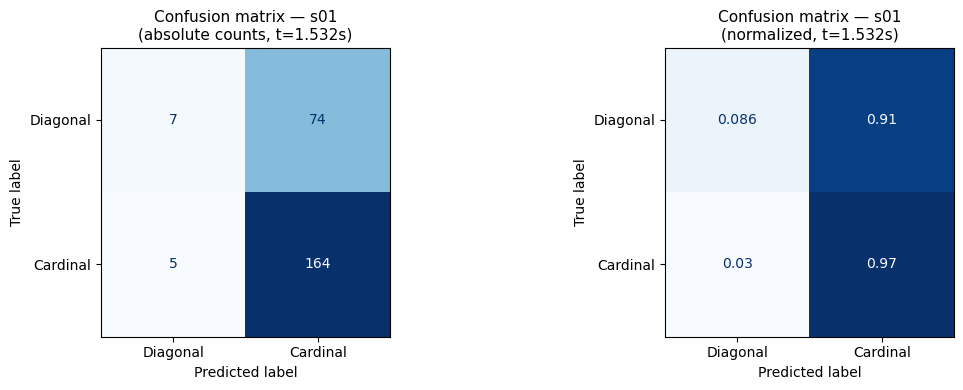


Accuracy media por grupo de canales (ventana de estimulos 1.0s → 2.5s):
------------------------------------------------------------
  Frontal              0.5843 ± 0.0117  (mejora sobre azar: 8.43%)
  Central              0.5935 ± 0.0123  (mejora sobre azar: 9.35%)
  Occipital            0.5895 ± 0.0124  (mejora sobre azar: 8.95%)
  All channels         0.5643 ± 0.0098  (mejora sobre azar: 6.43%)


In [ ]:
# VISUALIZACION DE PREDICCIONES TRIAL A TRIAL — TECNICA 2
# mostramos las predicciones individuales de un sujeto concreto
# usando los canales centrales timepoint a timepoint (igual que la tecnica 2)
# usamos el timepoint mas informativo — el pico de accuracy en la ventana de estimulos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# seleccionamos un sujeto de ejemplo
isubj_example = 0
print(f'Sujeto de ejemplo: {subjs_ok[isubj_example]}')

Y        = all_main_rawdata[isubj_example]['epoch_dat']
metadata = all_main_rawdata[isubj_example]['metadata'].reset_index(drop=True)
labels   = np.array(metadata['deci'], dtype=int)
folds    = create_folds(labels, n_folds)

# encontramos el timepoint con mayor accuracy para los canales centrales
# usando los resultados ya calculados en la tecnica 2
best_t = np.argmax(np.mean(scorer_ch['Central'], axis=0))
print(f'Timepoint mas informativo: t={time[best_t]:.3f}s (indice {best_t})')

# obtenemos las predicciones trial a trial en ese timepoint
ch_idx_central = ch_indices['Central']
preds_example  = decode_timepoint_deci_ch(best_t, Y, labels, folds, ch_idx_central)

# tabla de predicciones trial a trial
print(f'\nPredicciones trial a trial — {subjs_ok[isubj_example]} (t={time[best_t]:.3f}s)')
print(f'{"Trial":<8} {"Decision real":<18} {"Prediccion EEG":<18} {"Acierto":<8}')
print('-' * 55)

label_names = {0: 'DIAGONAL', 1: 'CARDINAL'}
aciertos    = 0
for i in range(len(labels)):
    real = label_names[labels[i]]
    pred = label_names[int(preds_example[i])] if not np.isnan(preds_example[i]) else 'N/A'
    ok   = 'SI' if real == pred else 'NO'
    if ok == 'SI':
        aciertos += 1
    if i < 20:
        print(f'{i+1:<8} {real:<18} {pred:<18} {ok:<8}')

print(f'...')
print(f'\nTotal trials: {len(labels)}')
print(f'Aciertos: {aciertos} ({aciertos/len(labels)*100:.1f}%)')

# Matriz de confusion 
valid   = ~np.isnan(preds_example)
cm      = confusion_matrix(labels[valid], preds_example[valid].astype(int))
cm_norm = confusion_matrix(labels[valid], preds_example[valid].astype(int), normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Diagonal', 'Cardinal'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion matrix — {subjs_ok[isubj_example]}\n'
                  f'(absolute counts, t={time[best_t]:.3f}s)', fontsize=11)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Diagonal', 'Cardinal'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion matrix — {subjs_ok[isubj_example]}\n'
                  f'(normalized, t={time[best_t]:.3f}s)', fontsize=11)

plt.tight_layout()
plt.show()

# Accuracy media por grupo de canales 
print('\nAccuracy media por grupo de canales (ventana de estimulos 1.0s → 2.5s):')
print('-' * 60)

idx_window = np.where((time >= 1.0) & (time <= 2.5))[0]

for group, scorer in scorer_ch.items():
    acc_mean = np.mean(scorer[:, idx_window])
    acc_sem  = np.std(np.mean(scorer[:, idx_window], axis=1)) / np.sqrt(nSubj)
    print(f'  {group:<20} {acc_mean:.4f} ± {acc_sem:.4f}  '
          f'(mejora sobre azar: {(acc_mean - 0.5)*100:.2f}%)')

Ventanas de acumulacion:
  O1→O1: 1.00s → 1.25s (126 timepoints)
  O1→O2: 1.00s → 1.50s (251 timepoints)
  O1→O3: 1.00s → 1.75s (376 timepoints)
  O1→O4: 1.00s → 2.00s (501 timepoints)
  O1→O5: 1.00s → 2.25s (626 timepoints)
  O1→O6: 1.00s → 2.50s (751 timepoints)
  subj s01 ✓  subj s02 ✓  subj s03 ✓  subj s04 ✓  subj s05 ✓  subj s07 ✓  subj s08 ✓  subj s09 ✓  subj s10 ✓  subj s11 ✓  subj s12 ✓  subj s13 ✓  subj s14 ✓  subj s15 ✓  subj s16 ✓  subj s17 ✓  subj s18 ✓  subj s19 ✓  subj s20 ✓  subj s21 ✓  subj s22 ✓  subj s23 ✓  subj s24 ✓  subj s25 ✓  subj s26 ✓  subj s27 ✓
acumulacion completada → 0.4 min transcurridos
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_accumulation.pkl


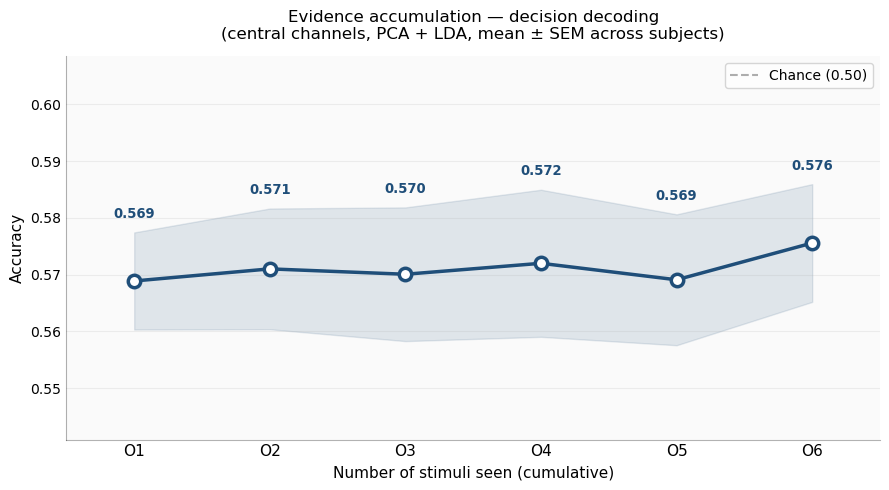

In [ ]:
# ACUMULACION DE EVIDENCIA — accuracy por numero de estimulos vistos 
# queremos ver si el clasificador mejora a medida que el participante ve mas estimulos
# esto conecta directamente con el DDM — el cerebro acumula evidencia estimulo a estimulo
# usamos los canales centrales (los mas informativos segun la tecnica 2)
# y vamos ampliando la ventana temporal un estimulo cada vez

# tiempos de onset de cada estimulo
# mascara inicial a 0.75s, estimulos cada 0.25s
t_onsets = [0.75 + 0.25 * (i + 1) for i in range(6)]  # [1.0, 1.25, 1.5, 1.75, 2.0, 2.25]
t_offset = 0.25  # duracion de cada estimulo

print('Ventanas de acumulacion:')
for i in range(6):
    t_ini = t_onsets[0]           # siempre empezamos desde O1
    t_fin = t_onsets[i] + t_offset # acabamos en el estimulo i+1
    idx_t = np.where((time >= t_ini) & (time <= t_fin))[0]
    print(f'  O1→O{i+1}: {t_ini:.2f}s → {t_fin:.2f}s ({len(idx_t)} timepoints)')

# array donde guardamos la accuracy por numero de estimulos (n_estimulos × n_sujetos)
scorer_accumulation = np.zeros((6, nSubj))

t_start = tm.time()

for isubj in range(nSubj):
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)
    folds    = create_folds(labels, n_folds)

    for i_stim in range(6):
        # ventana acumulada: desde O1 hasta el estimulo i_stim+1
        t_ini  = t_onsets[0]
        t_fin  = t_onsets[i_stim] + t_offset
        idx_t  = np.where((time >= t_ini) & (time <= t_fin))[0]

        # construimos la matriz de features con los canales centrales
        # y la ventana acumulada hasta este estimulo
        X = Y[:, central_idx, :][:, :, idx_t]  # (n_trials × 7 × n_t)
        X = X.reshape(X.shape[0], -1)           # (n_trials × 7*n_t)

        # pipeline: estandarizacion + PCA + LDA
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=min(n_components_pca, X.shape[0]-1, X.shape[1]))),
            ('clf',    LinearDiscriminantAnalysis())
        ])

        preds_all = np.full(len(labels), np.nan)
        for fold in folds:
            train_ix = fold['train_index']
            test_ix  = fold['test_index']
            if len(np.unique(labels[train_ix])) < 2:
                continue
            pipe.fit(X[train_ix], labels[train_ix])
            preds_all[test_ix] = pipe.predict(X[test_ix])

        valid = ~np.isnan(preds_all)
        scorer_accumulation[i_stim, isubj] = np.mean(
            preds_all[valid] == labels[valid].astype(float)
        )

    print(f'  subj {subjs_ok[isubj]} ✓', end='', flush=True)

elapsed = (tm.time() - t_start) / 60
print(f'\nacumulacion completada → {elapsed:.1f} min transcurridos')

# guardamos resultados
results_accum = {
    'scorer_accumulation': scorer_accumulation,
    'subjs_ok':            subjs_ok,
}

save_path_accum = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_accumulation.pkl'
with open(save_path_accum, 'wb') as f:
    pickle.dump(results_accum, f)

print(f'resultados guardados en: {save_path_accum}')

# plot mejorado — curva de acumulacion de evidencia
fig, ax = plt.subplots(figsize=(9, 5))

x = range(1, 7)

# area sombreada del SEM
ax.fill_between(x, accs_mean - accs_sem, accs_mean + accs_sem,
                color='#1f4e79', alpha=0.12, zorder=1)

# linea principal
ax.plot(x, accs_mean, color='#1f4e79', lw=2.5, zorder=3)

# puntos
ax.scatter(x, accs_mean, color='white', edgecolors='#1f4e79',
           s=80, linewidths=2.5, zorder=4)

# etiquetas de accuracy encima de cada punto
for i, (acc, sem) in enumerate(zip(accs_mean, accs_sem)):
    ax.text(i + 1, acc + sem + 0.002, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9.5,
            color='#1f4e79', fontweight='bold')

# linea de azar
ax.axhline(0.5, color='#999999', ls='--', lw=1.5, alpha=0.8,
           label='Chance (0.50)', zorder=2)

# etiquetas de cada estimulo en el eje X
ax.set_xticks(range(1, 7))
ax.set_xticklabels([f'O{i}' for i in range(1, 7)], fontsize=11)

# anotacion del numero de estimulos acumulados
ax.set_xlabel('Number of stimuli seen (cumulative)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)

# adaptamos el eje Y
y_min = accs_mean.min() - accs_sem.max() - 0.015
y_max = accs_mean.max() + accs_sem.max() + 0.02
ax.set_ylim([max(0.45, y_min), min(0.75, y_max)])
ax.set_xlim([0.5, 6.5])

# leyenda y titulo
ax.legend(fontsize=10, framealpha=0.8, edgecolor='#cccccc')
ax.set_title('Evidence accumulation — decision decoding\n'
             '(central channels, PCA + LDA, mean ± SEM across subjects)',
             fontsize=12, pad=12)

# estilo limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)
ax.tick_params(axis='both', which='both', length=0)
ax.grid(axis='y', alpha=0.2, linestyle='-', zorder=0)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

Canales centrales: ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
Indices: [6, 23, 22, 10, 21, 9, 20]

Ventana: Full trial (-0.5s → 5.25s)
  timepoints: 2876
  accuracy media: 0.5837 ± 0.0126

Ventana: Stimulus window (1.0s → 2.5s)
  timepoints: 751
  accuracy media: 0.5764 ± 0.0112

Ventana: Decision window (2.5s → 4.5s)
  timepoints: 1001
  accuracy media: 0.5747 ± 0.0095

Tecnica 4 completada → 0.6 min transcurridos
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_temporal.pkl


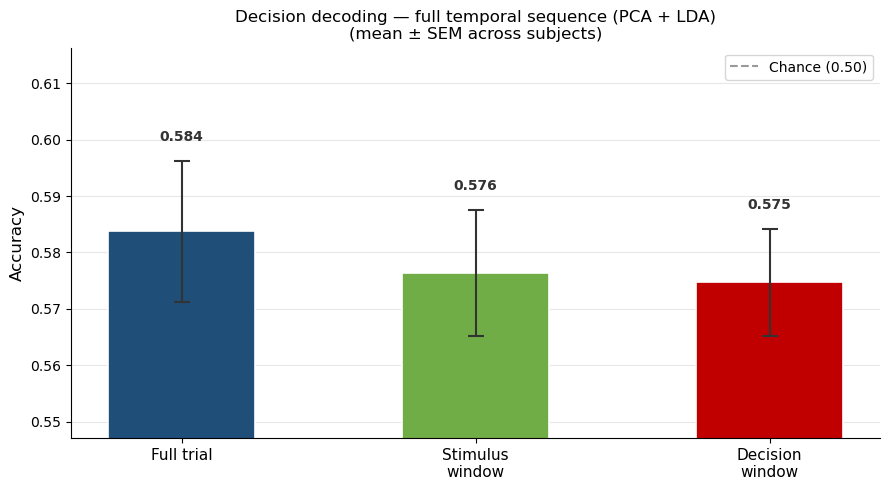

In [22]:
# TECNICA 3 — TODA LA SECUENCIA TEMPORAL COMO FEATURES 
# en vez de clasificar timepoint a timepoint, usamos toda la secuencia temporal
# completa de cada trial como features para predecir la decision
# usamos los canales centrales (los mas informativos segun la tecnica 2)
# como tenemos muchos features (canales × timepoints), reducimos la dimensionalidad
# con PCA antes de clasificar — esto evita el overfitting y mejora el clasificador

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# canales centrales — los mas informativos segun la tecnica 2
central_ch = ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
central_idx = [all_main_epochs[0].ch_names.index(ch) for ch in central_ch]
print(f'Canales centrales: {central_ch}')
print(f'Indices: {central_idx}')

# ventana temporal de interes: desde el inicio del trial hasta el final
# podemos probar diferentes ventanas para ver cual da mejor resultado
windows = {
    'Full trial (-0.5s → 5.25s)':   (None, None),       # todo el trial
    'Stimulus window (1.0s → 2.5s)': (1.0,  2.5),       # solo los estimulos
    'Decision window (2.5s → 4.5s)': (2.5,  4.5),       # solo la decision
}

# numero de componentes PCA — reducimos a 30 componentes
# esto captura la mayor parte de la varianza con muchos menos features
n_components_pca = 30

# resultados por ventana temporal
scorer_temporal = {}

t_start = tm.time()

for window_name, (t_ini, t_fin) in windows.items():
    print(f'\nVentana: {window_name}')

    # seleccionamos los indices de timepoints de esta ventana
    if t_ini is None:
        idx_t = np.arange(n_time)
    else:
        idx_t = np.where((time >= t_ini) & (time <= t_fin))[0]

    print(f'  timepoints: {len(idx_t)}')

    # accuracy por sujeto usando cross-validation de 5 folds
    accs = np.zeros(nSubj)

    for isubj in range(nSubj):
        Y        = all_main_rawdata[isubj]['epoch_dat']  # (n_trials × 32 × 2876)
        metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
        labels   = np.array(metadata['deci'], dtype=int)

        # construimos la matriz de features:
        # para cada trial cogemos los canales centrales en la ventana temporal
        # y aplanamos en un vector → (n_trials × (n_canales × n_timepoints))
        X = Y[:, :, :][:, central_idx, :][:, :, idx_t]  # (n_trials × 7 × n_t)
        X = X.reshape(X.shape[0], -1)                    # (n_trials × 7*n_t)

        # pipeline: PCA para reducir dimensionalidad + LDA para clasificar
        # usamos pipeline para que el PCA se ajuste solo en el training set
        # y no haya data leakage
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=min(n_components_pca, X.shape[0]-1, X.shape[1]))),
            ('clf',    LinearDiscriminantAnalysis())
        ])

        # cross-validation de 5 folds
        folds     = create_folds(labels, n_folds)
        preds_all = np.full(len(labels), np.nan)

        for fold in folds:
            train_ix = fold['train_index']
            test_ix  = fold['test_index']
            if len(np.unique(labels[train_ix])) < 2:
                continue
            pipe.fit(X[train_ix], labels[train_ix])
            preds_all[test_ix] = pipe.predict(X[test_ix])

        valid      = ~np.isnan(preds_all)
        accs[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))

    scorer_temporal[window_name] = accs
    print(f'  accuracy media: {accs.mean():.4f} ± {accs.std()/np.sqrt(nSubj):.4f}')

elapsed = (tm.time() - t_start) / 60
print(f'\nTecnica 4 completada → {elapsed:.1f} min transcurridos')

# guardamos resultados
results_temporal = {
    'scorer_temporal': scorer_temporal,
    'subjs_ok':        subjs_ok,
}

save_path_temporal = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_temporal.pkl'
with open(save_path_temporal, 'wb') as f:
    pickle.dump(results_temporal, f)

print(f'resultados guardados en: {save_path_temporal}')

# plot de barras comparando las diferentes ventanas temporales
fig, ax = plt.subplots(figsize=(9, 5))

window_names = list(scorer_temporal.keys())
accs_mean    = [scorer_temporal[w].mean() for w in window_names]
accs_sem     = [scorer_temporal[w].std() / np.sqrt(nSubj) for w in window_names]
colors_win   = ['#1f4e79', '#70ad47', '#c00000']

bars = ax.bar(range(len(window_names)), accs_mean,
              color=colors_win, width=0.5,
              edgecolor='white', linewidth=1.2, zorder=2)
ax.errorbar(range(len(window_names)), accs_mean, yerr=accs_sem,
            fmt='none', color='#333333', capsize=6, capthick=1.5, lw=1.5, zorder=3)

# etiquetas de accuracy encima de cada barra
for i, (acc, sem) in enumerate(zip(accs_mean, accs_sem)):
    ax.text(i, acc + sem + 0.003, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#333333')

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8,
           label='Chance (0.50)', zorder=1)

y_min = min(accs_mean) - max(accs_sem) - 0.015
y_max = max(accs_mean) + max(accs_sem) + 0.02
ax.set_ylim([max(0.45, y_min), min(0.75, y_max)])

ax.set_xticks(range(len(window_names)))
ax.set_xticklabels(['Full trial', 'Stimulus\nwindow', 'Decision\nwindow'],
                    fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding — full temporal sequence (PCA + LDA)\n'
             '(mean ± SEM across subjects)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()

Features por trial: 7 canales × 2876 timepoints = 20132

Ventana: Full trial (-0.5s → 5.25s)
  timepoints: 2876
  accuracy media: 0.5830 ± 0.0116

Ventana: Stimulus window (1.0s → 2.5s)
  timepoints: 751
  accuracy media: 0.5767 ± 0.0115

Ventana: Decision window (2.5s → 4.5s)
  timepoints: 1001
  accuracy media: 0.5805 ± 0.0101

Tecnica 2+4 completada → 0.7 min transcurridos
resultados guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_combined.pkl


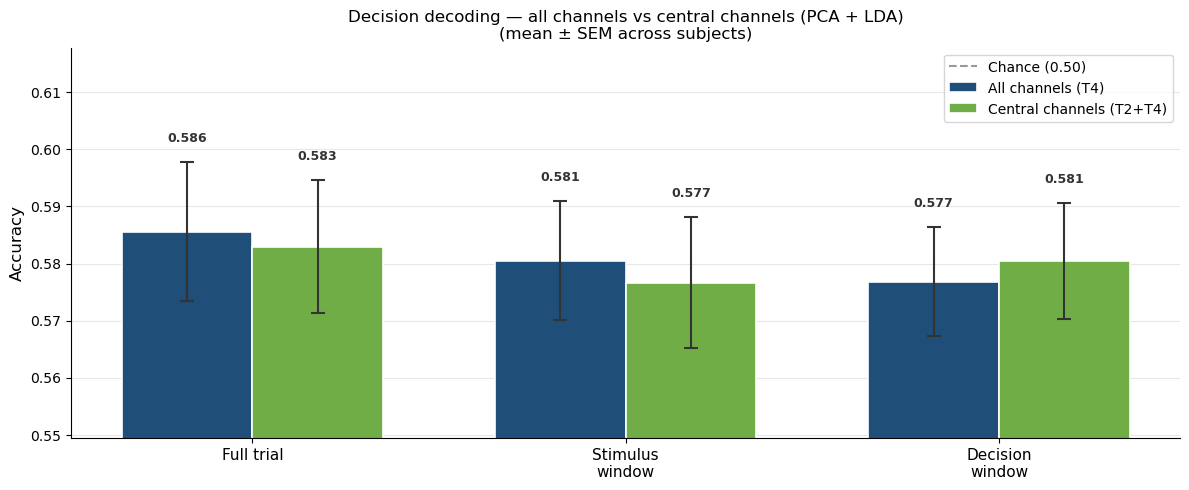

In [16]:
# TECNICA 2 + 3 — CANALES CENTRALES + SECUENCIA TEMPORAL COMPLETA 
# combinamos las dos tecnicas anteriores:
# usamos solo los canales centrales (los mas informativos segun la tecnica 2)
# y toda la secuencia temporal completa como features (tecnica 4)
# reducimos la dimensionalidad con PCA antes de clasificar

print(f'Features por trial: {len(central_idx)} canales × {n_time} timepoints = {len(central_idx)*n_time}')

# ventanas temporales a comparar — igual que en la tecnica 4
windows = {
    'Full trial (-0.5s → 5.25s)':    (None, None),
    'Stimulus window (1.0s → 2.5s)': (1.0,  2.5),
    'Decision window (2.5s → 4.5s)': (2.5,  4.5),
}

n_components_pca = 30
scorer_combined  = {}

t_start = tm.time()

for window_name, (t_ini, t_fin) in windows.items():
    print(f'\nVentana: {window_name}')

    # seleccionamos los indices de timepoints de esta ventana
    if t_ini is None:
        idx_t = np.arange(n_time)
    else:
        idx_t = np.where((time >= t_ini) & (time <= t_fin))[0]

    print(f'  timepoints: {len(idx_t)}')

    accs = np.zeros(nSubj)

    for isubj in range(nSubj):
        Y        = all_main_rawdata[isubj]['epoch_dat']
        metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
        labels   = np.array(metadata['deci'], dtype=int)

        # construimos la matriz de features con solo los canales centrales
        # y la ventana temporal seleccionada
        X = Y[:, central_idx, :][:, :, idx_t]  # (n_trials × 7 × n_t)
        X = X.reshape(X.shape[0], -1)           # (n_trials × 7*n_t)

        # pipeline: estandarizacion + PCA + LDA
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=min(n_components_pca, X.shape[0]-1, X.shape[1]))),
            ('clf',    LinearDiscriminantAnalysis())
        ])

        folds     = create_folds(labels, n_folds)
        preds_all = np.full(len(labels), np.nan)

        for fold in folds:
            train_ix = fold['train_index']
            test_ix  = fold['test_index']
            if len(np.unique(labels[train_ix])) < 2:
                continue
            pipe.fit(X[train_ix], labels[train_ix])
            preds_all[test_ix] = pipe.predict(X[test_ix])

        valid       = ~np.isnan(preds_all)
        accs[isubj] = np.mean(preds_all[valid] == labels[valid].astype(float))

    scorer_combined[window_name] = accs
    print(f'  accuracy media: {accs.mean():.4f} ± {accs.std()/np.sqrt(nSubj):.4f}')

elapsed = (tm.time() - t_start) / 60
print(f'\nTecnica 2+4 completada → {elapsed:.1f} min transcurridos')

# guardamos resultados
results_combined = {
    'scorer_combined': scorer_combined,
    'subjs_ok':        subjs_ok,
}

save_path_combined = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_combined.pkl'
with open(save_path_combined, 'wb') as f:
    pickle.dump(results_combined, f)

print(f'resultados guardados en: {save_path_combined}')

# plot comparando tecnica 4 (todos los canales) vs tecnica 2+4 (canales centrales)
fig, ax = plt.subplots(figsize=(12, 5))

window_labels = ['Full trial', 'Stimulus\nwindow', 'Decision\nwindow']
x             = np.arange(len(window_labels))
width         = 0.35

# tecnica 4 — todos los canales
accs_t4  = [scorer_temporal[w].mean() for w in windows]
sems_t4  = [scorer_temporal[w].std() / np.sqrt(nSubj) for w in windows]

# tecnica 2+4 — canales centrales
accs_c   = [scorer_combined[w].mean() for w in windows]
sems_c   = [scorer_combined[w].std() / np.sqrt(nSubj) for w in windows]

bars1 = ax.bar(x - width/2, accs_t4, width, color='#1f4e79',
               edgecolor='white', linewidth=1.2, label='All channels (T4)', zorder=2)
bars2 = ax.bar(x + width/2, accs_c,  width, color='#70ad47',
               edgecolor='white', linewidth=1.2, label='Central channels (T2+T4)', zorder=2)

ax.errorbar(x - width/2, accs_t4, yerr=sems_t4,
            fmt='none', color='#333333', capsize=5, capthick=1.5, lw=1.5, zorder=3)
ax.errorbar(x + width/2, accs_c,  yerr=sems_c,
            fmt='none', color='#333333', capsize=5, capthick=1.5, lw=1.5, zorder=3)

# etiquetas encima de cada barra
for i, (acc, sem) in enumerate(zip(accs_t4, sems_t4)):
    ax.text(i - width/2, acc + sem + 0.003, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
for i, (acc, sem) in enumerate(zip(accs_c, sems_c)):
    ax.text(i + width/2, acc + sem + 0.003, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8, label='Chance (0.50)', zorder=1)

y_min = min(accs_t4 + accs_c) - max(sems_t4 + sems_c) - 0.015
y_max = max(accs_t4 + accs_c) + max(sems_t4 + sems_c) + 0.02
ax.set_ylim([max(0.45, y_min), min(0.75, y_max)])

ax.set_xticks(x)
ax.set_xticklabels(window_labels, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding — all channels vs central channels (PCA + LDA)\n'
             '(mean ± SEM across subjects)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()